# ASSIGNMENT 2 — AIML — Electricity Consumption Analysis

Dataset: [UCI Individual Household Electric Power Consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

print("All libraries imported successfully ✓")

All libraries imported successfully ✓


## Data Loading & Preprocessing

In [ ]:
FILE_PATH = "household_power_consumption.txt"   

df = pd.read_csv(
    FILE_PATH,
    sep=";",
    low_memory=False,
    na_values=["?"],
)


df["Datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"],
                                format="%d/%m/%Y %H:%M:%S")
df.set_index("Datetime", inplace=True)
df.drop(columns=["Date", "Time"], inplace=True)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")

Shape: (2075259, 7)
Date range: 2006-12-16 17:24:00 → 2010-11-26 21:02:00

Missing values per column:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


---
## Task 1 — Exploratory Data Analysis (EDA)

### 1a. Time-Series Trend of Global Active Power

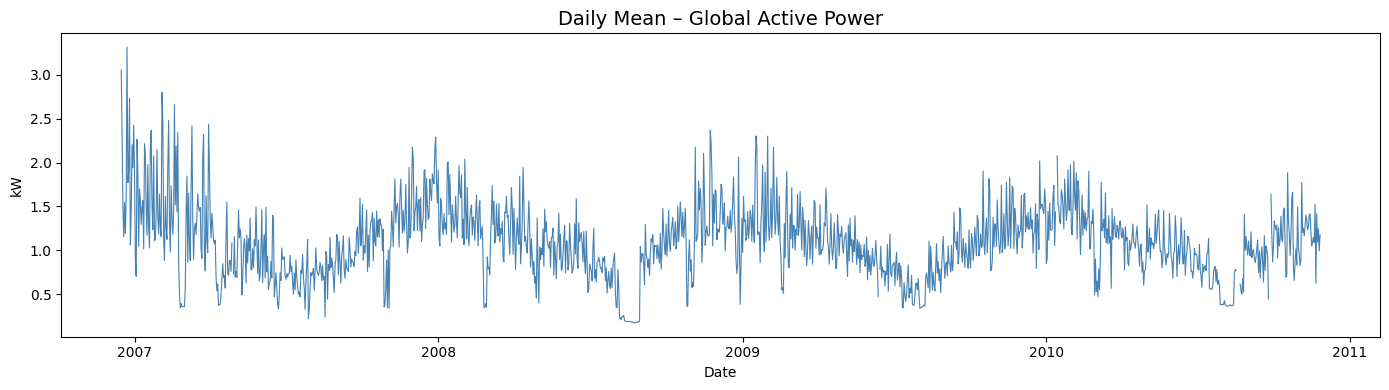

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
daily_gap = df["Global_active_power"].resample("D").mean()
ax.plot(daily_gap.index, daily_gap.values, linewidth=0.8, color="steelblue")
ax.set_title("Daily Mean – Global Active Power", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("kW")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

### 1b. Missing / Abnormal Readings

In [4]:
Q1 = df["Global_active_power"].quantile(0.25)
Q3 = df["Global_active_power"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR
outlier_mask = (df["Global_active_power"] < lower) | (df["Global_active_power"] > upper)
print(f"Missing readings : {df['Global_active_power'].isnull().sum()}")
print(f"Outliers (IQR×3): {outlier_mask.sum()} readings  (range: {lower:.3f} – {upper:.3f} kW)")

Missing readings : 25979
Outliers (IQR×3): 14376 readings  (range: -3.352 – 5.188 kW)


### 1c. Hourly and Daily Patterns

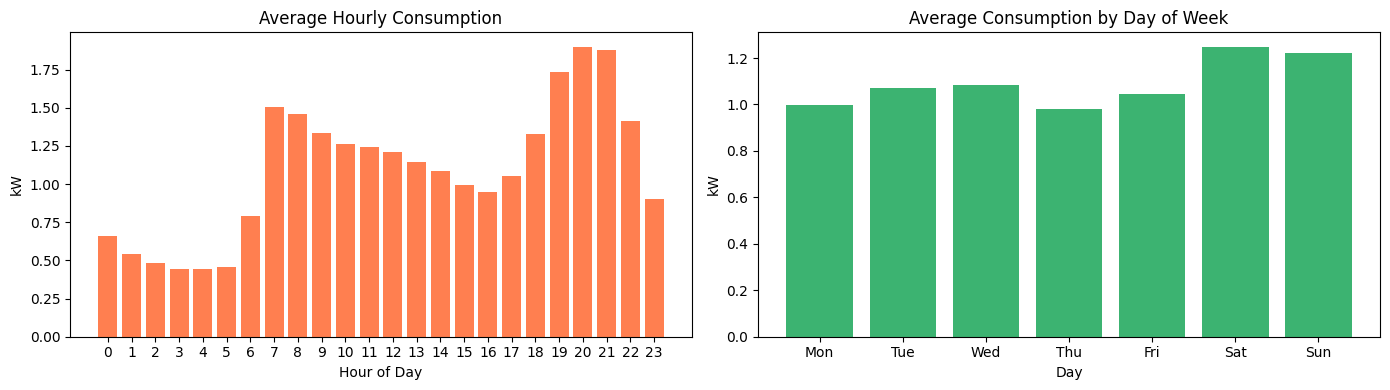

Peak usage hour : 20:00  (1.899 kW avg)
Low  usage hour : 4:00  (0.444 kW avg)


In [5]:
df_clean = df.dropna(subset=["Global_active_power"])

hourly_avg = df_clean["Global_active_power"].groupby(df_clean.index.hour).mean()
daily_avg  = df_clean["Global_active_power"].groupby(df_clean.index.dayofweek).mean()
day_names  = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(hourly_avg.index, hourly_avg.values, color="coral")
axes[0].set_title("Average Hourly Consumption")
axes[0].set_xlabel("Hour of Day"); axes[0].set_ylabel("kW")
axes[0].set_xticks(range(0, 24))

axes[1].bar(daily_avg.index, daily_avg.values, color="mediumseagreen", tick_label=day_names)
axes[1].set_title("Average Consumption by Day of Week")
axes[1].set_xlabel("Day"); axes[1].set_ylabel("kW")

plt.tight_layout(); plt.show()

peak_hour = int(hourly_avg.idxmax())
low_hour  = int(hourly_avg.idxmin())
print(f"Peak usage hour : {peak_hour}:00  ({hourly_avg[peak_hour]:.3f} kW avg)")
print(f"Low  usage hour : {low_hour}:00  ({hourly_avg[low_hour]:.3f} kW avg)")

---
## Task 2 — Supervised Learning: Time-Series Forecasting

### 2a & 2b. Prepare Windowed Time-Series Data

In [ ]:
hourly_df = df["Global_active_power"].resample("h").mean().dropna()

WINDOW = 24   

def make_lag_features(series, window):
    data = series.values
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i - window: i])
        y.append(data[i])
    return np.array(X), np.array(y)

X, y = make_lag_features(hourly_df, WINDOW)
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 27315 | Test samples: 6829


### 2c. Train Linear Regression Model

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model trained ✓")

Model trained ✓


### 2d. Evaluate Model

In [8]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100

print(f"MAE  : {mae:.4f} kW")
print(f"RMSE : {rmse:.4f} kW")
print(f"MAPE : {mape:.2f} %")

MAE  : 0.3712 kW
RMSE : 0.5213 kW
MAPE : 49.16 %


### 2e. Predicted vs Actual Plot

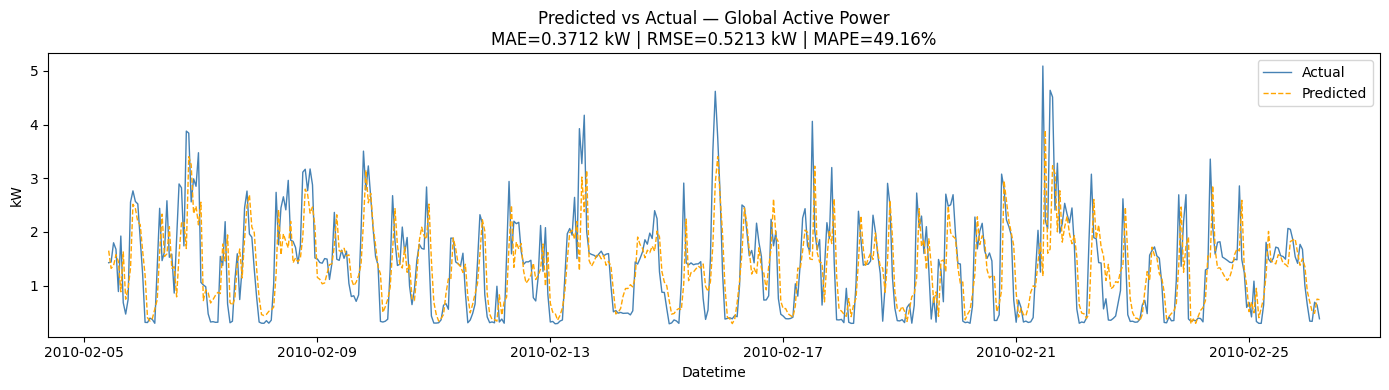

In [9]:
test_index = hourly_df.index[WINDOW + split: WINDOW + split + len(y_test)]
plot_n = min(500, len(y_test))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_index[:plot_n], y_test[:plot_n],  label="Actual",    color="steelblue",  linewidth=1)
ax.plot(test_index[:plot_n], y_pred[:plot_n],  label="Predicted", color="orange",     linewidth=1, linestyle="--")
ax.set_title(f"Predicted vs Actual — Global Active Power\nMAE={mae:.4f} kW | RMSE={rmse:.4f} kW | MAPE={mape:.2f}%")
ax.set_xlabel("Datetime"); ax.set_ylabel("kW"); ax.legend()
plt.tight_layout(); plt.show()

---
## Task 3 — Unsupervised Learning

### 3a. Anomaly Detection — Isolation Forest

Anomalies detected: 20492


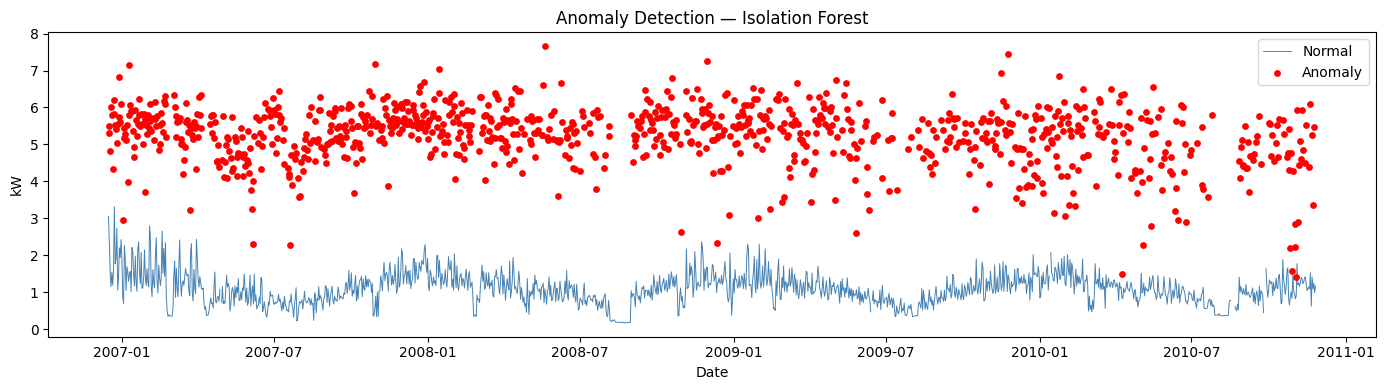

In [10]:
feature_cols = ["Global_active_power","Global_reactive_power","Voltage","Global_intensity"]
df_feat = df[feature_cols].dropna().copy()

iso_forest = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
df_feat["anomaly"] = iso_forest.fit_predict(df_feat[feature_cols])
print(f"Anomalies detected: {(df_feat['anomaly'] == -1).sum()}")

fig, ax = plt.subplots(figsize=(14, 4))
daily_gap2 = df_feat["Global_active_power"].resample("D").mean()
ax.plot(daily_gap2.index, daily_gap2.values, color="steelblue", linewidth=0.7, label="Normal")
anom_daily = df_feat[df_feat["anomaly"] == -1]["Global_active_power"].resample("D").mean().dropna()
ax.scatter(anom_daily.index, anom_daily.values, color="red", s=15, zorder=5, label="Anomaly")
ax.set_title("Anomaly Detection — Isolation Forest")
ax.set_xlabel("Date"); ax.set_ylabel("kW"); ax.legend()
plt.tight_layout(); plt.show()

### 3b. Daily Consumption Profile Clustering

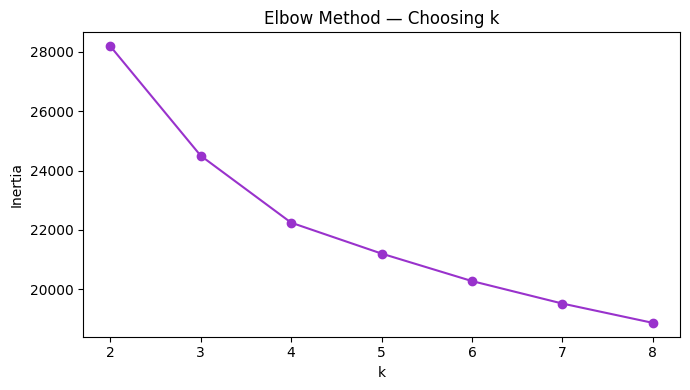

In [ ]:
hourly_profile = (
    df_clean["Global_active_power"]
    .groupby([df_clean.index.date, df_clean.index.hour])
    .mean()
    .unstack(level=1)
    .dropna()
)
hourly_profile.columns = [f"h{c}" for c in hourly_profile.columns]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(hourly_profile)


inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, marker="o", color="darkorchid")
ax.set_title("Elbow Method — Choosing k"); ax.set_xlabel("k"); ax.set_ylabel("Inertia")
plt.tight_layout(); plt.show()

### 3c. Visualize Clusters (k=3)

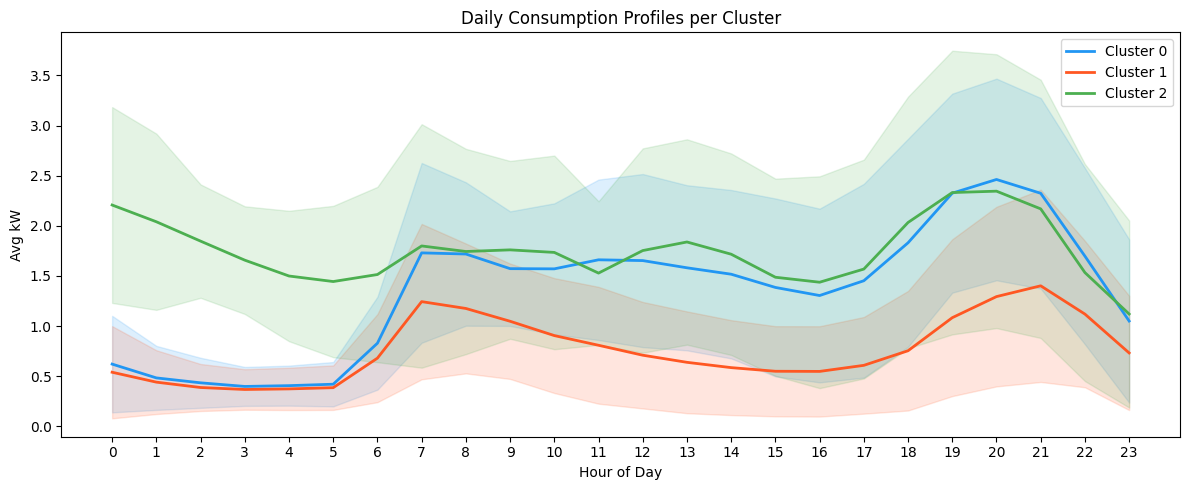

In [12]:
K_BEST = 3
km_final = KMeans(n_clusters=K_BEST, random_state=42, n_init=10)
hourly_profile["cluster"] = km_final.fit_predict(X_cluster)

cluster_colors = ["#2196F3", "#FF5722", "#4CAF50"]
fig, ax = plt.subplots(figsize=(12, 5))
hours = range(24)
for c in range(K_BEST):
    profile_c = hourly_profile[hourly_profile["cluster"] == c].drop(columns="cluster")
    mean_p = profile_c.mean()
    ax.plot(hours, mean_p.values, label=f"Cluster {c}", color=cluster_colors[c], linewidth=2)
    ax.fill_between(hours, (mean_p - profile_c.std()).values,
                    (mean_p + profile_c.std()).values, alpha=0.15, color=cluster_colors[c])
ax.set_title("Daily Consumption Profiles per Cluster")
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Avg kW"); ax.set_xticks(range(24)); ax.legend()
plt.tight_layout(); plt.show()

### 3d. Cluster Characteristics

In [13]:
hour_cols = [c for c in hourly_profile.columns if c != "cluster"]
thresholds = hourly_profile[hour_cols].sum(axis=1).quantile([0.33, 0.66])
for c in range(K_BEST):
    g = hourly_profile[hourly_profile["cluster"] == c][hour_cols]
    total = g.sum(axis=1).mean()
    if total < thresholds[0.33]:
        label = "Low-Use"
    elif total > thresholds[0.66]:
        label = "High-Use"
    else:
        label = "Medium-Use"
    peak_h = g.mean().idxmax()
    print(f"Cluster {c} [{label}] → {len(g)} days | Daily avg: {total:.2f} kWh | Peak: {peak_h}")

Cluster 0 [High-Use] → 671 days | Daily avg: 32.43 kWh | Peak: h20
Cluster 1 [Low-Use] → 676 days | Daily avg: 18.37 kWh | Peak: h21
Cluster 2 [High-Use] → 70 days | Daily avg: 42.11 kWh | Peak: h20


---
## Task 4 — AI Task: Simple Rule-Based Consumption Category Generator

In [17]:
GAP_MEAN = df["Global_active_power"].mean()
GAP_STD  = df["Global_active_power"].std()
LOW_THRESHOLD  = GAP_MEAN - 0.5 * GAP_STD
HIGH_THRESHOLD = GAP_MEAN + 0.5 * GAP_STD

SUGGESTIONS = {
    "Low Usage":    " Great! Consumption is low. Schedule heavy tasks (laundry, dishwasher) during off-peak hours.",
    "Medium Usage": " Moderate usage. Check standby devices and switch to LED lighting to save more.",
    "High Usage":   " High usage! Turn off non-essential appliances or shift heavy loads to night-time.",
}

def classify_usage(predicted_gap: float):
    if predicted_gap < LOW_THRESHOLD:
        category = "Low Usage"
    elif predicted_gap <= HIGH_THRESHOLD:
        category = "Medium Usage"
    else:
        category = "High Usage"
    return category, SUGGESTIONS[category]

print(f"Thresholds → Low: <{LOW_THRESHOLD:.3f} kW | Medium: {LOW_THRESHOLD:.3f}–{HIGH_THRESHOLD:.3f} kW | High: >{HIGH_THRESHOLD:.3f} kW\n")
for val in [0.25, 1.10, 3.50]:
    cat, sug = classify_usage(val)
    print(f"Predicted: {val:.2f} kW  →  Category: {cat}")
    print(f"  Suggestion: {sug}\n")

Thresholds → Low: <0.563 kW | Medium: 0.563–1.620 kW | High: >1.620 kW

Predicted: 0.25 kW  →  Category: Low Usage
  Suggestion:  Great! Consumption is low. Schedule heavy tasks (laundry, dishwasher) during off-peak hours.

Predicted: 1.10 kW  →  Category: Medium Usage
  Suggestion:  Moderate usage. Check standby devices and switch to LED lighting to save more.

Predicted: 3.50 kW  →  Category: High Usage
  Suggestion:  High usage! Turn off non-essential appliances or shift heavy loads to night-time.



Category distribution in test predictions:
Medium Usage    3994
Low Usage       1800
High Usage      1035


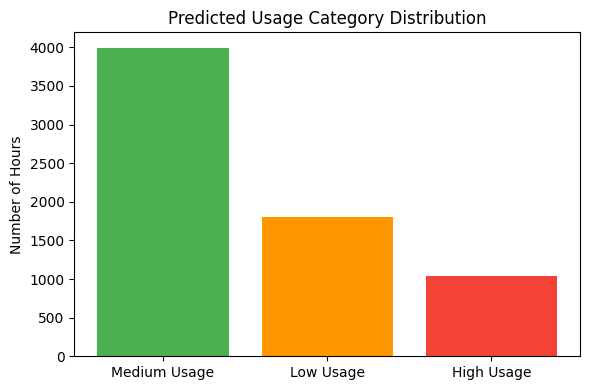

In [18]:

categories  = [classify_usage(p)[0] for p in y_pred]
cat_counts  = pd.Series(categories).value_counts()
print("Category distribution in test predictions:")
print(cat_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cat_counts.index, cat_counts.values, color=["#4CAF50","#FF9800","#F44336"])
ax.set_title("Predicted Usage Category Distribution")
ax.set_ylabel("Number of Hours")
plt.tight_layout(); plt.show()